
# 08 Target Scene Modeling and Echo Synthesis

## Purpose

This notebook turns the single-echo examples from Notebook 06 and the chirp ideas from Notebook 07 into a simple scene model. The goal is to show how a received record can be synthesized as the sum of multiple delayed, scaled echoes produced by multiple targets at different ranges.

## Prerequisites

- Notebook 06: Sonar Basics, Propagation, and Time of Flight
- Notebook 07: Chirps, Pulse Compression, and Range Resolution
- Basic comfort with superposition and delayed signals

## Learning Objectives

By the end of this notebook, you should be able to:

- describe a simple target scene as a set of point reflectors,
- explain how each reflector contributes a delayed and scaled copy of the transmitted pulse,
- synthesize a received record from multiple target returns,
- interpret how overlapping echoes arise from scene geometry,
- and connect scene reflectivity to the matched-filter output.



## New Terms In This Notebook

- **Target scene**: the collection of reflectors or objects that can return echoes to the sonar.
- **Point reflector**: an idealized reflector treated as if all of its return comes from one location.
- **Reflectivity**: a scalar weight describing how strongly a target reflects the transmitted waveform in the simplified model.
- **Echo synthesis**: constructing a received signal by summing modeled echoes from one or more reflectors.
- **Scene response**: the total received waveform produced by the whole target scene.
- **Superposition**: the principle that the total response is the sum of the responses from the individual targets.
- **Two-target scene**: a simple scene model containing two point reflectors at different ranges.
- **$M$**: the number of point reflectors in the scene model.
- **Overlap**: the situation in which two echoes occupy the same time region in the received record.



## Big Picture

Earlier notebooks focused on one target at a time so that delay, matched filtering, and pulse compression could be understood cleanly. Real scenes are not one target. They are many reflectors, each with its own range and strength.

The big idea of this notebook is that a simple sonar scene model is just a sum of echo copies. Once we can synthesize those sums, we can start asking richer questions about overlap, resolution, and later image formation.


## Mathematical Definitions and Relevant Intuition

### One Reflector

For one point reflector at range $R_m$ with reflectivity $a_m$, the round-trip delay is

$$
\tau_m = \frac{2R_m}{c},
$$

where $c$ is propagation speed. This is the same time-of-flight relationship used in Notebook 06 and is consistent with the basic time-of-flight definition summarized in the [Wikipedia Time of flight article](https://en.wikipedia.org/wiki/Time_of_flight).

If the transmitted waveform is $s(t)$, then the simplest echo model is

$$
r_m(t) = a_m \, s(t - \tau_m).
$$

Here $a_m$ scales the echo amplitude, and $\tau_m$ shifts it in time.

### Multiple Reflectors And Superposition

For a scene containing $M$ point reflectors, where $M$ is the number of reflectors in the scene, the received signal is modeled as

$$
r(t) = \, \sum_{m=1}^{M} a_m \, s(t - \tau_m).
$$

This is the key scene-modeling equation for the notebook. Each reflector contributes one delayed, scaled copy of the transmit waveform, and the total received record is their sum. That sum is the direct scene-model version of the [Wikipedia Superposition principle article](https://en.wikipedia.org/wiki/Superposition_principle).

### Discrete-Time Echo Synthesis

After sampling at rate $f_s$, each delay becomes a sample offset

$$
n_m \approx \tau_m f_s,
$$

so a simple discrete scene model is

$$
r[n] = \, \sum_{m=1}^{M} a_m \, s[n - n_m].
$$

This is the equation we use in code. It is only a simple sampled approximation, but it is enough to show how multi-target scenes produce the received record.

### Why This Matters

Once the received signal is a sum of multiple echoes, matched filtering no longer produces only one peak. It produces a response shaped by the whole scene. That is the bridge from isolated-target examples to later notebooks on beamforming, aperture synthesis, and image formation.


In [1]:

import matplotlib.pyplot as plt
import numpy as np

from _bootstrap import bootstrap_src_path

bootstrap_src_path()

from sonar_py_lib.dsp import matched_filter, normalize, time_axis
from sonar_py_lib.notebook_utils import set_plot_style
from sonar_py_lib.plotting import make_figure, plot_signal

set_plot_style()


def linear_chirp(duration_s: float, sample_rate_hz: float, start_freq_hz: float, bandwidth_hz: float) -> tuple[np.ndarray, np.ndarray]:
    num_samples = int(round(duration_s * sample_rate_hz))
    t = time_axis(num_samples, sample_rate_hz)
    sweep_rate = bandwidth_hz / duration_s
    phase = 2.0 * np.pi * (start_freq_hz * t + 0.5 * sweep_rate * t**2)
    return t, np.real(np.exp(1j * phase))


def synthesize_scene(record_len: int, pulse: np.ndarray, target_ranges_m: np.ndarray, target_weights: np.ndarray, c_sound: float, fs: float) -> tuple[np.ndarray, np.ndarray]:
    record = np.zeros(record_len, dtype=float)
    sample_delays = []
    for rng_m, weight in zip(target_ranges_m, target_weights):
        tau = 2.0 * rng_m / c_sound
        delay_n = int(round(tau * fs))
        stop = min(record_len, delay_n + len(pulse))
        usable = stop - delay_n
        if usable > 0:
            record[delay_n:stop] += weight * pulse[:usable]
        sample_delays.append(delay_n)
    return record, np.array(sample_delays, dtype=int)



## Assumptions

- We model the scene as a small set of ideal point reflectors.
- We ignore multipath, Doppler, beam pattern effects, and environment-dependent propagation changes.
- We use one fixed transmit waveform and a constant propagation speed.
- We treat reflectivity as a simple scalar amplitude weight in this notebook.



## One Scene, Several Echoes

The first figure is meant to show the basic scene model directly. We define three point reflectors at different ranges and synthesize the received record as the sum of their delayed chirp echoes.

The main things to watch are the target labels in the left panel, the dotted echo-arrival lines in the right panel, and the matching left-to-right ordering between them. The received record is not one special waveform. It is the superposition of several delayed copies of the same transmit pulse.


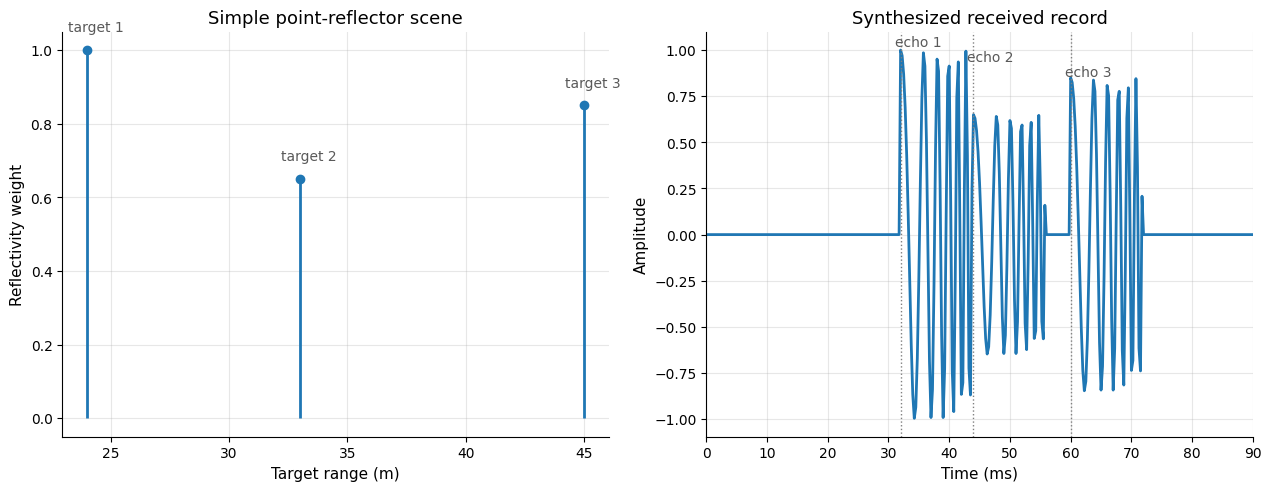

Target 1: range  24.0 m -> echo time  32.00 ms
Target 2: range  33.0 m -> echo time  44.00 ms
Target 3: range  45.0 m -> echo time  60.00 ms


In [2]:

fs = 4000.0
c_sound = 1500.0
pulse_duration_s = 0.012
_, tx_pulse = linear_chirp(pulse_duration_s, fs, start_freq_hz=150.0, bandwidth_hz=700.0)

target_ranges_m = np.array([24.0, 33.0, 45.0])
target_weights = np.array([1.0, 0.65, 0.85])
record_len = int(round(0.12 * fs))
received_scene, sample_delays = synthesize_scene(record_len, tx_pulse, target_ranges_m, target_weights, c_sound, fs)
t_record = time_axis(record_len, fs)
echo_times_ms = 1000.0 * sample_delays / fs

fig, axes = make_figure(nrows=1, ncols=2, figsize=(12.6, 4.8), sharex=False)
axes[0].stem(target_ranges_m, target_weights, basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0].set_title('Simple point-reflector scene')
axes[0].set_xlabel('Target range (m)')
axes[0].set_ylabel('Reflectivity weight')
for idx, (rng_m, wt) in enumerate(zip(target_ranges_m, target_weights), start=1):
    axes[0].text(rng_m - 0.8, wt + 0.05, f'target {idx}', color='0.35')

plot_signal(t_record * 1000.0, received_scene, ax=axes[1], title='Synthesized received record', xlabel='Time (ms)', ylabel='Amplitude')
for idx, tau_ms in enumerate(echo_times_ms, start=1):
    axes[1].axvline(tau_ms, color='0.5', linestyle=':', linewidth=1.0)
    axes[1].text(tau_ms - 1.0, 1.02 - 0.08 * (idx - 1), f'echo {idx}', color='0.35')
axes[1].set_xlim(0, 90)
plt.show()

for idx, (rng_m, tau_ms) in enumerate(zip(target_ranges_m, echo_times_ms), start=1):
    print(f'Target {idx}: range {rng_m:>5.1f} m -> echo time {tau_ms:>6.2f} ms')



Each target contributes one delayed copy of the transmit waveform. The farther the target, the later its echo appears. The stronger the reflectivity weight, the stronger that contribution appears in the sum.

This is the basic scene-synthesis idea that later imaging notebooks rely on: geometry determines delay, reflectivity sets the echo weight in this simplified model, and the received record is their superposition. In later notebooks, propagation effects such as range-dependent loss will also affect amplitude.



## Overlap Happens When Targets Are Close Enough In Delay

The next figure is meant to show what changes when two targets are close together in range. We compare a well-separated two-target scene against a closely spaced two-target scene using the same chirp pulse.

The lesson to watch is whether the raw received record shows two clearly separate echo regions or one blended region, with the dotted lines marking the true echo arrival times. This is where the scene model starts to connect directly to the range-resolution ideas from Notebook 07.


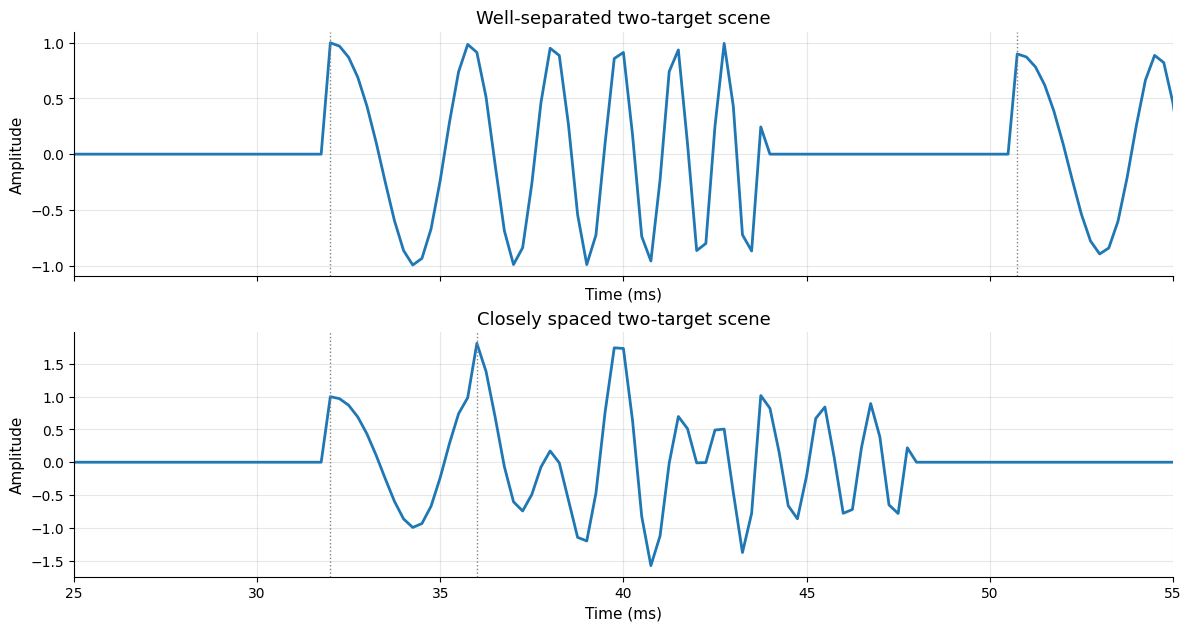

Well-separated scene delay difference: 18.75 ms
Close scene delay difference: 4.00 ms


In [3]:

well_sep_ranges = np.array([24.0, 38.0])
close_ranges = np.array([24.0, 27.0])
weights = np.array([1.0, 0.9])
record_sep, delays_sep = synthesize_scene(record_len, tx_pulse, well_sep_ranges, weights, c_sound, fs)
record_close, delays_close = synthesize_scene(record_len, tx_pulse, close_ranges, weights, c_sound, fs)

fig, axes = make_figure(nrows=2, ncols=1, figsize=(11.8, 6.2), sharex=True)
plot_signal(t_record * 1000.0, record_sep, ax=axes[0], title='Well-separated two-target scene', xlabel='Time (ms)', ylabel='Amplitude')
plot_signal(t_record * 1000.0, record_close, ax=axes[1], title='Closely spaced two-target scene', xlabel='Time (ms)', ylabel='Amplitude')
for ax, ds in zip(axes, [delays_sep, delays_close]):
    for d in ds:
        ax.axvline(1000.0 * d / fs, color='0.5', linestyle=':', linewidth=1.0)
    ax.set_xlim(25, 55)
plt.show()

print(f'Well-separated scene delay difference: {1000.0 * (delays_sep[1] - delays_sep[0]) / fs:.2f} ms')
print(f'Close scene delay difference: {1000.0 * (delays_close[1] - delays_close[0]) / fs:.2f} ms')



When the targets are well separated, the received record contains two distinct echo regions. When the targets are closer together, the echoes overlap and the raw waveform becomes harder to interpret by eye.

That overlap is not a special new phenomenon. It is still just superposition. The only difference is that the delays are now close enough that the delayed copies of the transmit waveform occupy the same time interval.



## The Matched Filter Responds To The Whole Scene

The final figure is meant to show how the scene appears after matched filtering. We apply the matched filter to the same well-separated and closely spaced two-target scenes.

The key thing to watch is how the matched-filter output reflects the scene structure. For the well-separated case, the response should show two distinct peaks. For the closely spaced case, those peaks move closer together and become harder to separate.


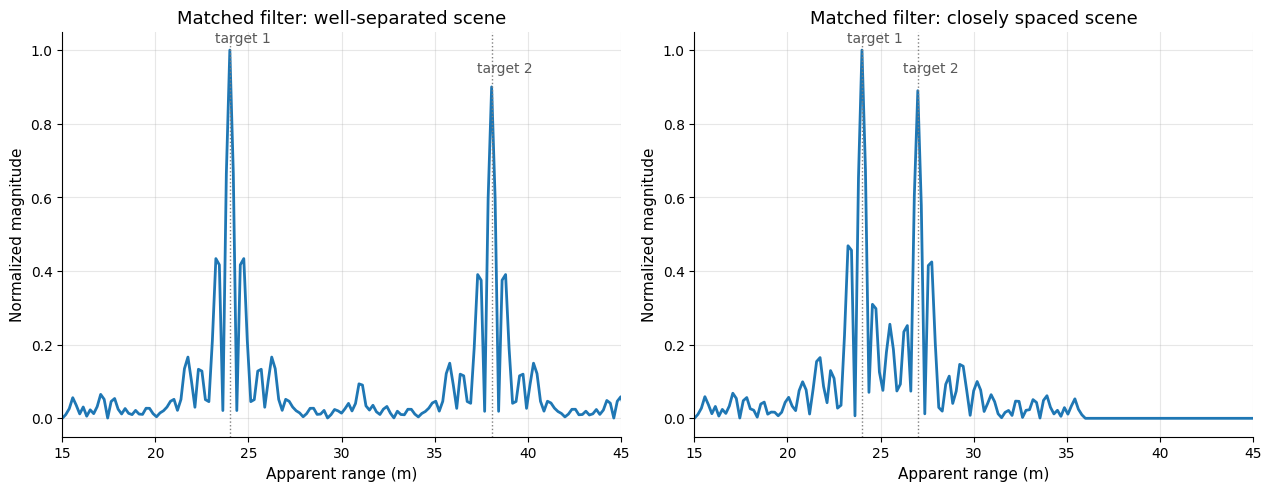

In [4]:

mf_sep = matched_filter(record_sep, tx_pulse, mode='full')
mf_close = matched_filter(record_close, tx_pulse, mode='full')
lags = np.arange(-(len(tx_pulse) - 1), len(record_sep))
range_axis_m = 0.5 * c_sound * (lags / fs)
true_ranges_sep = 0.5 * c_sound * (delays_sep / fs)
true_ranges_close = 0.5 * c_sound * (delays_close / fs)

fig, axes = make_figure(nrows=1, ncols=2, figsize=(12.6, 4.8), sharex=False)
plot_signal(range_axis_m, normalize(np.abs(mf_sep)), ax=axes[0], title='Matched filter: well-separated scene', xlabel='Apparent range (m)', ylabel='Normalized magnitude')
plot_signal(range_axis_m, normalize(np.abs(mf_close)), ax=axes[1], title='Matched filter: closely spaced scene', xlabel='Apparent range (m)', ylabel='Normalized magnitude')
for ax, true_ranges in zip(axes, [true_ranges_sep, true_ranges_close]):
    for idx, rng_m in enumerate(true_ranges, start=1):
        ax.axvline(rng_m, color='0.5', linestyle=':', linewidth=1.0)
        ax.text(rng_m - 0.8, 1.02 - 0.08 * (idx - 1), f'target {idx}', color='0.35')
    ax.set_xlim(15, 45)
plt.show()



The matched filter does not recover the scene by magic. It still responds to the summed waveform. But by concentrating energy near the correct delays, it makes the scene structure much easier to interpret.

This is the main scene-modeling bridge to the next stage of the curriculum: once we can synthesize scenes and interpret their matched-filter responses, we can start asking how array geometry and beamforming change what the scene looks like.



## Tradeoffs And Limitations

Several practical limitations are already visible in this simplified scene model:

- Point-reflector scenes are useful for intuition, but real targets may be extended and angle-dependent.
- Overlap becomes harder to interpret when targets are close in delay or have different amplitudes.
- This notebook models reflectivity as a simple scalar, but real reflections can also change waveform shape and phase.
- Matched filtering helps localize delays, but it does not remove all ambiguity when targets are too close together.



## References

- [Wikipedia Time of flight article](https://en.wikipedia.org/wiki/Time_of_flight)
- [Wikipedia Superposition principle article](https://en.wikipedia.org/wiki/Superposition_principle)



## Recap

- A simple target scene can be modeled as a set of delayed, scaled copies of the transmit pulse.
- Each target range sets an echo delay through the two-way travel equation.
- Reflectivity weights control how strongly each target contributes to the received record.
- Overlap arises naturally when multiple echoes occupy the same time region.
- The matched filter responds to the whole scene and makes the delay structure easier to interpret.



## Suggested Next Questions

- What changes when targets differ not only in range but also in angle?
- How should we model extended targets instead of point reflectors?
- How do arrays and beamforming help separate overlapping scene contributions?

The next notebook turns from one-dimensional scene synthesis to array geometry and spatial sampling.
